### Imports

In [1]:
!pip install transformers

In [2]:
import torch
from tqdm.notebook import tqdm

from torch.utils.data import TensorDataset

# from google.colab import drive
import pandas as pd

import nltk
import re
import numpy as np
nltk.download('wordnet')
nltk.download('stopwords')
from nltk.corpus import stopwords
from  nltk.stem import SnowballStemmer

import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib as mpl

from sklearn.model_selection import train_test_split
from sklearn.utils import compute_class_weight

[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Data Load

In [3]:
!pwd

/kaggle/working


In [4]:
# drive.mount('/content/drive')
path = '/kaggle/input/app-corp-split-data/'
df = pd.read_csv('/kaggle/input/app-corp-split-data/APP_CORP_SPLIT_DATA.csv')
print(df.shape)

(16333, 4)


In [5]:
labels_ = [
  'policy_introductory',
  'cookies_and_similar_technologies',
  'third_party_share_and_collection',
  'user_right_and_control',
  'data_security',
  'data_retention',
  'international_data_transfer',
  'specific_audiences',
  'policy_change',
  'policy_contact_information']

In [6]:
label_dict = ['policy_introductory',
            'first_party_collection_and_use',
            'cookies_and_similar_technologies',
            'data_retention',
            'third_party_share_and_collection',
            'data_security',
            'international_data_transfer',
            'user_right_and_control',
            'specific_audiences',
            'policy_change',
            'policy_contact_information']

### Downsampling the majority class

In [7]:
# class_counts = df['label'].value_counts()
# majority_class = class_counts.idxmax()

# majority_class_df = df[(df['label'] == majority_class) & (df['data_type'] == 'train')]
# downsampled_majority_class_df = majority_class_df.sample(n=2300, random_state=42)

# conjuntos = ['val', 'test']

# major_test_val = df[(df['label'] == majority_class) & (df['data_type'].isin(conjuntos))]

# balanced_df = pd.concat([df[df['label'].isin(labels_)], major_test_val, downsampled_majority_class_df])
# balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

# df = balanced_df
# df.head()

In [8]:
# df.groupby(['label', 'clase', 'data_type']).count()
df.groupby(['clase', 'data_type']).count()

text  label
clase data_type             
0     test        127    127
      train      1023   1023
      val         114    114
1     test        533    533
      train      4313   4313
      val         479    479
2     test        118    118
      train       954    954
      val         106    106
3     test         38     38
      train       310    310
      val          35     35
4     test        286    286
      train      2316   2316
      val         257    257
5     test         82     82
      train       663    663
      val          74     74
6     test         40     40
      train       326    326
      val          36     36
7     test        237    237
      train      1921   1921
      val         213    213
8     test         75     75
      train       604    604
      val          67     67
9     test         52     52
      train       423    423
      val          47     47
10    test         46     46
      train       376    376
      val          42     42

### Clean Data

In [9]:
stop_words = stopwords.words("english")

stemmer = SnowballStemmer("english")

def clean_text(text):
  TEXT_CLEANING_RE = "@\S+|https?:\S+|http?:\S|[^A-Za-z0-9]+"
  TEXT_CLEANING_RE_EXTRA = "[^\w\s]"
  text = re.sub(TEXT_CLEANING_RE, ' ', str(text).lower()).strip()
  text = re.sub(TEXT_CLEANING_RE_EXTRA, ' ', str(text).lower()).strip()
  return text

def preprocess(text,cleaning=True,stopwords=False,stemming=False):
    if cleaning:
      text = clean_text(text)
    tokens = []
    for token in text.split():
        if (not stopwords) or (stopwords and (token not in stop_words)):
            if stemming:
                tokens.append(stemmer.stem(token))
            else:
                tokens.append(token)
    return " ".join(tokens)

In [10]:
df['cleaned_text'] = df['text'].apply(lambda x: preprocess(x))

### Hiperparametros

In [11]:
BATCH_SIZE = 16
DROPOUT = 0.1
LEARNING_RATE = 1e-6
EPSILON = 1e-8
EPOCH = 5
WEIGHTED = True


SEED = 17
NUM_LABELS = 11
MODEL_NAME = 'roberta-base'
MAX_LENGTH = 128

In [12]:
import random

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

### Prepare Input for BERT

In [13]:
# from transformers import AutoTokenizer
from transformers import RobertaTokenizer, RobertaModel, AdamW, get_linear_schedule_with_warmup

# tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer = RobertaTokenizer.from_pretrained(MODEL_NAME)

def encode_data(df, set_name, MAX_LENGTH):
    encoded_data = tokenizer.batch_encode_plus(
        list(df[df.data_type==set_name].text.values),
        add_special_tokens=True,
        return_attention_mask=True,
        return_token_type_ids=True,
        pad_to_max_length=True,
        max_length=MAX_LENGTH,
        return_tensors='pt'
    )

    dataset = TensorDataset(encoded_data['input_ids'],
                            encoded_data['attention_mask'],
                            encoded_data['token_type_ids'],
                            torch.tensor(df[df.data_type==set_name].clase.values))

    return dataset

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

In [14]:
dataset_train = encode_data(df, 'train', MAX_LENGTH)
dataset_val = encode_data(df, 'val', MAX_LENGTH)
dataset_test = encode_data(df, 'test', MAX_LENGTH)

Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
/opt/conda/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:2619: FutureWarning: The `pad_to_max_length` argument is deprecated and will be removed in a future version, use `padding=True` or `padding='longest'` to pad to the longest sequence in the batch, or use `padding='max_length'` to pad to a max length. In this case, you can give a specific length with `max_length` (e.g. `max_length=45`) or leave max_length to None to pad to the maximal input size of the model (e.g. 512 for Bert).
  warnings.warn(


In [15]:
len(dataset_train), len(dataset_val), len(dataset_test)

(13229, 1470, 1634)

In [16]:
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler

dataloader_train = DataLoader(dataset_train,
                              sampler=RandomSampler(dataset_train),
                              batch_size=BATCH_SIZE)

dataloader_validation = DataLoader(dataset_val,
                                   sampler=SequentialSampler(dataset_val),
                                   batch_size=BATCH_SIZE)

dataloader_test = DataLoader(dataset_test,
                            sampler=SequentialSampler(dataset_test),
                            batch_size=BATCH_SIZE)

### Model Arquitecture

In [17]:
# from transformers import AutoModelForSequenceClassification
# from transformers import AutoConfig

# configuration = AutoConfig.from_pretrained(MODEL_NAME)
# configuration.num_labels = NUM_LABELS
# configuration.output_attentions = False
# configuration.output_hidden_states = False
# configuration.classifier_dropout = DROPOUT

# model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME,
#                                                       config = configuration)

In [18]:
# Model with extra layers on top of RoBERTa
class ROBERTAClassifier(torch.nn.Module):
    def __init__(self, dropout_rate=0.3):
        super(ROBERTAClassifier, self).__init__()
        
        self.roberta = RobertaModel.from_pretrained('roberta-base', return_dict=False)
        self.d1 = torch.nn.Dropout(dropout_rate)
        self.l1 = torch.nn.Linear(768, 64)
        self.bn1 = torch.nn.LayerNorm(64)
        self.d2 = torch.nn.Dropout(dropout_rate)
        self.l2 = torch.nn.Linear(64, 32)
        self.l3 = torch.nn.Linear(32, 11)
        
    def forward(self, input_ids, attention_mask):
        _, x = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        x = self.d1(x)
        x = self.l1(x)
        x = self.bn1(x)
        x = torch.nn.Tanh()(x)
        x = self.d2(x)
        x = self.l2(x)
        x = self.l3(x)
        
        return x  

In [19]:
model = ROBERTAClassifier(DROPOUT)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [20]:
from transformers import AdamW, get_linear_schedule_with_warmup

optimizer = AdamW(model.parameters(),
                  betas=(0.9, 0.999),
                  lr=LEARNING_RATE,
                  eps=EPSILON)

scheduler = get_linear_schedule_with_warmup(optimizer,
                                            num_warmup_steps=0,
                                            num_training_steps=len(dataloader_train)*EPOCH)

/opt/conda/lib/python3.10/site-packages/transformers/optimization.py:429: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


In [21]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np

def metrics(preds, labels):
    preds_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    acc = accuracy_score(labels_flat, preds_flat)
    metric = precision_recall_fscore_support(labels_flat, preds_flat, average='macro')
    return acc, metric[0], metric[1], metric[2]

In [22]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

ROBERTAClassifier(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): L

### Focal loss

In [23]:
# import torch.nn as nn
# import torch.nn.functional as F

# class FocalLoss(nn.Module):
#     def __init__(self, alpha=1, gamma=2, reduction='mean'):
#         super(FocalLoss, self).__init__()
#         self.alpha = alpha
#         self.gamma = gamma
#         self.reduction = reduction

#     def forward(self, inputs, targets):
#         ce_loss = F.cross_entropy(inputs, targets, reduction='none')
#         pt = torch.exp(-ce_loss)
#         focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss

#         if self.reduction == 'mean':
#             return focal_loss.mean()
#         elif self.reduction == 'sum':
#             return focal_loss.sum()
#         else:
#             return focal_loss

### Compute class weights

In [24]:
nSamples = df[df['data_type'] == 'train']['clase'].value_counts().sort_index().values
class_weights = [1 - (x / sum(nSamples)) for x in nSamples]
class_weights = torch.FloatTensor(class_weights).to(device)
class_weights

tensor([0.9227, 0.6740, 0.9279, 0.9766, 0.8249, 0.9499, 0.9754, 0.8548, 0.9543,
        0.9680, 0.9716], device='cuda:0')

In [25]:
# class_series = df[df.data_type=='train'].clase.values
# class_labels = np.unique(class_series)
# pesos = compute_class_weight(class_weight='balanced', classes=class_labels, y=class_series)
# class_weights = torch.tensor(pesos, dtype=torch.float32).to(device)
# # class_weights = dict(zip(class_labels, pesos))
# class_weights

### Entrenamiento y validacion

In [26]:
def evaluate(dataloader_val, WEIGHTED):

    model.eval()

    loss_val_total = 0
    predictions, true_vals = [], []

    for batch in dataloader_val:

        batch = tuple(b.to(device) for b in batch)

#         inputs = {'input_ids':      batch[0],
#                   'attention_mask': batch[1],
#                   'token_type_ids': batch[2],
#                   'labels':         batch[3]
#                  }

        with torch.no_grad():
#             outputs = model(**inputs)
              outputs = model(input_ids=batch[0],  
                           attention_mask=batch[1])

        if WEIGHTED:
#               criterion = FocalLoss(alpha=1, gamma=2)
              criterion = torch.nn.CrossEntropyLoss(weight=class_weights)
#             loss = criterion(outputs['logits'], inputs['labels'])
              loss = criterion(outputs, batch[3])
        else:
            loss = outputs['loss']

#         logits = outputs['logits']
        loss_val_total += loss.item()

#         logits = logits.detach().cpu().numpy()
#         label_ids = inputs['labels'].cpu().numpy()
        label_ids = batch[3].cpu().numpy()
#         predictions.append(logits) outputs
        predictions.append(outputs.detach().cpu().numpy())
        true_vals.append(label_ids)

    loss_val_avg = loss_val_total/len(dataloader_val)

    predictions = np.concatenate(predictions, axis=0)
    true_vals = np.concatenate(true_vals, axis=0)

    return loss_val_avg, predictions, true_vals

In [27]:
path_model = '/content/drive/MyDrive/Memoria_Group_Classification/Modelos/'

train_loss_history = []
val_loss_history = []

print('Loss weighted : ', WEIGHTED)

for epoch in tqdm(range(1, EPOCH+1)):

    model.train()

    loss_train_total = 0

    progress_bar = tqdm(dataloader_train, desc='Epoch {:1d}'.format(epoch), leave=False, disable=False)
    for batch in progress_bar:

        model.zero_grad()

        batch = tuple(b.to(device) for b in batch)

#         inputs = {'input_ids':      batch[0],
#                   'attention_mask': batch[1],
#                   'token_type_ids': batch[2],
#                   'labels':         batch[3]
#                  }

#         outputs = model(**inputs)
        outputs = model(input_ids=batch[0],  
                           attention_mask=batch[1])

        if WEIGHTED:
#             criterion = FocalLoss(alpha=1, gamma=2)
            criterion = torch.nn.CrossEntropyLoss(weight=class_weights)
#             loss = criterion(outputs['logits'], inputs['labels']) 
            loss = criterion(outputs, batch[3])
        else:
            loss = outputs['loss']

        loss_train_total += loss.item()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

        progress_bar.set_postfix({'training_loss': '{:.3f}'.format(loss.item()/len(batch))})

    torch.save(model.state_dict(), f'finetuned_V2_BERT_epoch_{epoch}.model')

    tqdm.write(f'\nEpoch {epoch}')

    loss_train_avg = loss_train_total/len(dataloader_train)
    tqdm.write(f'Training loss: {loss_train_avg}')

    val_loss, predictions, true_vals = evaluate(dataloader_validation, WEIGHTED)
    acc, precision, recall, f1 = metrics(predictions, true_vals)

    train_loss_history.append(loss_train_avg)
    val_loss_history.append(val_loss)

    tqdm.write(f'Validation loss: {val_loss}')
    tqdm.write(f'Accuracy: {acc} - Precision: {precision} - Recall : {recall} - F1 Score : {f1} (Validation)')

Loss weighted :  True


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1:   0%|          | 0/827 [00:00<?, ?it/s]


Epoch 1
Training loss: 2.0827625148097435
Validation loss: 1.8388796370962393
Accuracy: 0.507482993197279 - Precision: 0.366179373400408 - Recall : 0.2692158223088028 - F1 Score : 0.2623488941386371 (Validation)


/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


...

Epoch 4:   0%|          | 0/827 [00:00<?, ?it/s]


Epoch 4
Training loss: 1.6543856709294624
Validation loss: 1.5981795230637426
Accuracy: 0.6564625850340136 - Precision: 0.6332942772805396 - Recall : 0.5359277471273888 - F1 Score : 0.5653332095762477 (Validation)


/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Epoch 5:   0%|          | 0/827 [00:00<?, ?it/s]


Epoch 5
Training loss: 1.6266731927588023
Validation loss: 1.5878695988136788
Accuracy: 0.6585034013605442 - Precision: 0.721263884097159 - Recall : 0.5438693021455069 - F1 Score : 0.5738483994934004 (Validation)


In [27]:
def get_confusion_matrix(y_true, y_pred, class_names):
  fig, ax = plt.subplots(figsize=(6, 6))
  cm = confusion_matrix(y_true, y_pred)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
  plt.rcParams.update({'font.size': 9})
  plt.rc('xtick', labelsize=9)
  plt.rc('ytick', labelsize=9)
  plt.xlabel('Predicted Label', fontsize=9)
  plt.ylabel('True Label', fontsize=9)
  disp = disp.plot(ax=ax,cmap=plt.cm.Greens, xticks_rotation='vertical')
  plt.show()

In [28]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
def plot_metrics(train_history, val_history, metrics = ['accuracy', 'F1']):

    plt.plot(train_history, color='blue', label='train')
    plt.plot(val_history,
             color='orange', label='val')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.ylim([0, plt.ylim()[1]])
    plt.legend();

In [29]:
val_labels = []
for _, _, _, labels in dataloader_validation:
    for x in labels:
        val_labels.append(x.item())

In [30]:
_, predictions, true_vals = evaluate(dataloader_validation, WEIGHTED)
y_pred = predictions.argmax(axis=1)

In [32]:
print(classification_report(val_labels, y_pred, target_names=label_dict))

                                  precision    recall  f1-score   support



             policy_introductory       0.75      0.75      0.75       114

  first_party_collection_and_use       0.82      0.76      0.79       479

cookies_and_similar_technologies       0.75      0.72      0.73       106

                  data_retention       0.71      0.69      0.70        35

third_party_share_and_collection       0.73      0.79      0.76       257

                   data_security       0.78      0.84      0.81        74

     international_data_transfer       0.62      0.72      0.67        36

          user_right_and_control       0.65      0.74      0.69       213

              specific_audiences       0.88      0.76      0.82        67

                   policy_change       0.93      0.85      0.89        47

      policy_contact_information       0.71      0.57      0.63        42



                        accuracy                           0.75      1470

                     

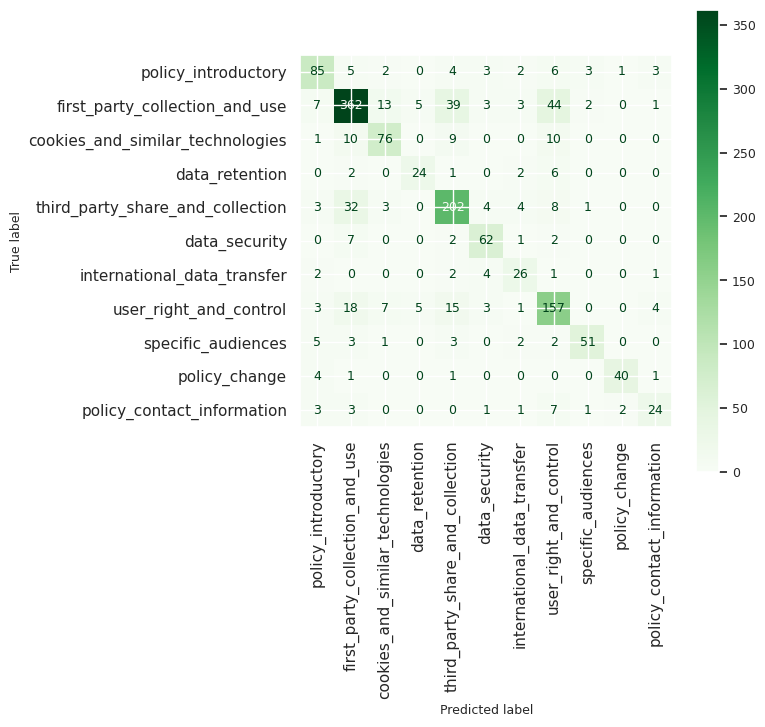

In [33]:
get_confusion_matrix(val_labels, y_pred, label_dict)

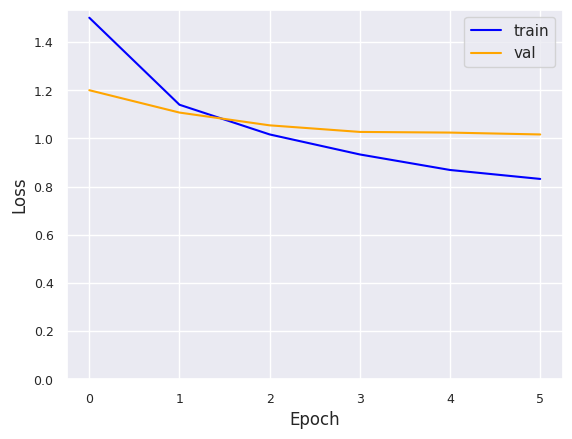

In [34]:
plot_metrics(train_loss_history, val_loss_history)

In [35]:
from transformers import AutoConfig

# configuration = AutoConfig.from_pretrained(MODEL_NAME)
# configuration.num_labels = NUM_LABELS
# configuration.output_attentions = False
# configuration.output_hidden_states = False
# configuration.classifier_dropout = DROPOUT


# model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME,
#                                                       config = configuration)

model = ROBERTAClassifier(DROPOUT)

model.to(device)

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']

You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ROBERTAClassifier(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): L

In [36]:
epoch = 3
model.load_state_dict(torch.load( f'finetuned_V2_BERT_epoch_{epoch}.model', map_location=torch.device('cuda'))) # path_model

<All keys matched successfully>

In [37]:
_, predictions, true_vals = evaluate(dataloader_validation, WEIGHTED)
y_pred = predictions.argmax(axis=1)

In [38]:
print(classification_report(val_labels, y_pred, target_names=label_dict))

                                  precision    recall  f1-score   support



             policy_introductory       0.73      0.75      0.74       114

  first_party_collection_and_use       0.85      0.72      0.78       479

cookies_and_similar_technologies       0.74      0.71      0.72       106

                  data_retention       0.62      0.69      0.65        35

third_party_share_and_collection       0.69      0.82      0.75       257

                   data_security       0.76      0.81      0.78        74

     international_data_transfer       0.59      0.72      0.65        36

          user_right_and_control       0.66      0.73      0.69       213

              specific_audiences       0.85      0.78      0.81        67

                   policy_change       0.89      0.85      0.87        47

      policy_contact_information       0.73      0.57      0.64        42



                        accuracy                           0.75      1470

                     

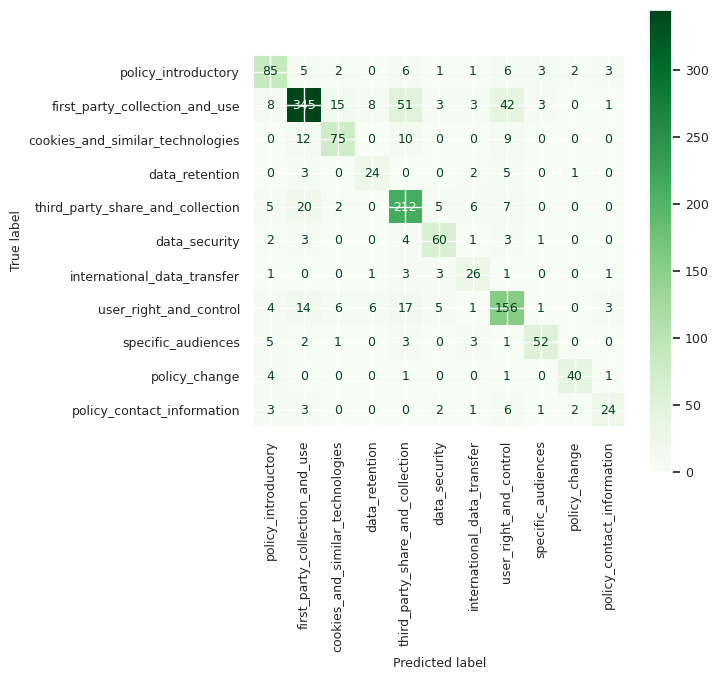

In [39]:
get_confusion_matrix(val_labels, y_pred, label_dict)

In [37]:
path_model = '/content/drive/MyDrive/Memoria_Group_Classification/Modelos/'

epoch = 3

torch.save(model.state_dict(),path_model + f'finetuned_Roberta_epoch_{epoch}_BEST_MODEL.model')